In [22]:
%%capture
%load_ext autoreload
%autoreload 3

In [30]:
#carrega o dataset
#!/bin/bash
!curl -L -o ~/Downloads/beginner-chest-xray-image-classification.zip\
  https://www.kaggle.com/api/v1/datasets/download/vivek468/beginner-chest-xray-image-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2127M  100 2127M    0     0  26.2M      0  0:01:21  0:01:21 --:--:-- 28.6M


In [38]:
%%capture
%pip install -q numpy pandas matplotlib pillow --break-system-packages
%pip install tensorflow --break-system-packages
%pip install flatbuffers --upgrade --break-system-packages
%pip install torch torchvision --break-system-packages

In [39]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # False no Raspberry Pi, é normal

2.10.0+cpu
False


In [45]:
import os, matplotlib.pyplot as plt, numpy as np, urllib.request, zipfile, torch, torch.nn as nn
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [37]:
#carrega o datasset
URL = "https://www.kaggle.com/api/v1/datasets/download/vivek468/beginner-chest-xray-image-classification"
DATASET_DIR = os.path.join(os.getcwd(), 'chest_xray')
ZIP_PATH = os.path.join(os.getcwd(), 'dataset.zip')

if not os.path.exists(DATASET_DIR):
    print("Baixando dataset...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    
    print("Descomprimindo...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(os.getcwd())
    
    os.remove(ZIP_PATH)  # apaga o zip após extrair
    print("Pronto!")
else:
    print("Dataset já existe, pulando download.")

Baixando dataset...
Descomprimindo...
Pronto!


In [13]:
base_dir = os.path.join(".", "data", "chest_xray")

In [14]:
base_dir

'./data/chest_xray'

In [5]:
# Contar imagens em cada split
for split in ['train', 'test', 'pred']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} imagens")

train/NORMAL: 3432 imagens
train/PNEUMONIA: 3883 imagens
test/NORMAL: 234 imagens
test/PNEUMONIA: 386 imagens
pred/NORMAL: 4 imagens
pred/PNEUMONIA: 5 imagens


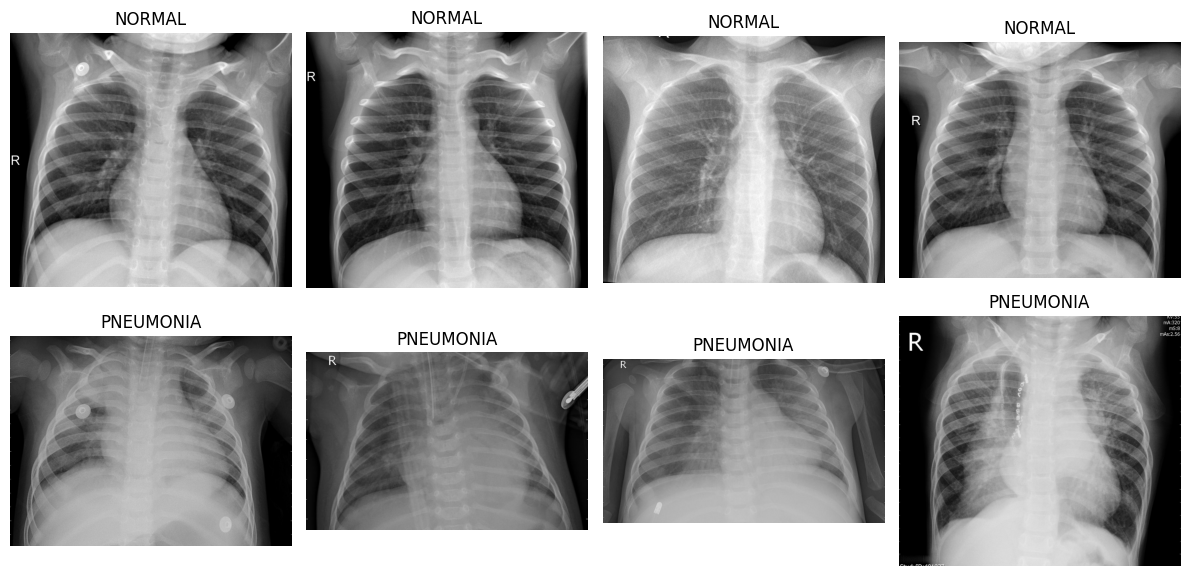

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    path = os.path.join(base_dir, 'train', label)
    images = os.listdir(path)[:4]
    
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(path, img_name))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(label)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [19]:
path = os.path.join(base_dir, 'train', 'NORMAL')
imagens = os.listdir(path)

tamanhos = []
modos = []

for img_name in imagens:
    img = Image.open(os.path.join(path, img_name))
    tamanhos.append(img.size)  # (largura, altura)
    modos.append(img.mode)     # RGB, L, etc.

tamanhos = np.array(tamanhos)

print(f"Largura  — min: {tamanhos[:,0].min()}, max: {tamanhos[:,0].max()}, média: {tamanhos[:,0].mean():.0f}")
print(f"Altura   — min: {tamanhos[:,1].min()}, max: {tamanhos[:,1].max()}, média: {tamanhos[:,1].mean():.0f}")
print(f"Modos encontrados: {set(modos)}")

Largura  — min: 912, max: 2916, média: 1677
Altura   — min: 496, max: 2713, média: 1379
Modos encontrados: {'RGB', 'L'}


In [20]:
def carregar_imagem(caminho, tamanho=(224, 224)):
    img = Image.open(caminho)
    img = img.convert('RGB')        # padroniza para 3 canais
    img = img.resize(tamanho)       # redimensiona
    img = np.array(img)             # converte para array numpy
    img = img / 255.0               # normaliza pixels para [0, 1]
    return img

# Teste com uma imagem
img_teste = carregar_imagem(os.path.join(base_dir, 'train', 'NORMAL', os.listdir(os.path.join(base_dir, 'train', 'NORMAL'))[0]))

print(f"Shape: {img_teste.shape}")        # deve ser (224, 224, 3)
print(f"Min: {img_teste.min():.2f}")      # deve ser 0.0
print(f"Max: {img_teste.max():.2f}")      # deve ser 1.0

Shape: (224, 224, 3)
Min: 0.00
Max: 1.00


In [41]:
base_dir = os.path.join(os.getcwd(), 'chest_xray')

# Transformações para treino (com augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),             # converte para tensor e normaliza [0,1]
])

# Transformações para teste (sem augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=train_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(base_dir, 'test'),  transform=test_transforms)

# DataLoaders (carregam em batches)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Verificar
print(f"Classes: {train_dataset.classes}")
print(f"Treino:  {len(train_dataset)} imagens")
print(f"Teste:   {len(test_dataset)} imagens")

Classes: ['NORMAL', 'PNEUMONIA']
Treino:  7315 imagens
Teste:   620 imagens


In [42]:
print(train_dataset.class_to_idx)
# {'NORMAL': 0, 'PNEUMONIA': 1}

{'NORMAL': 0, 'PNEUMONIA': 1}


In [43]:
imagens, rotulos = next(iter(train_loader))

print(f"Shape do batch de imagens: {imagens.shape}")
print(f"Shape dos rótulos:         {rotulos.shape}")
print(f"Valores min/max:           {imagens.min():.2f} / {imagens.max():.2f}")
print(f"Rótulos no batch:          {rotulos.unique()}")

Shape do batch de imagens: torch.Size([32, 3, 224, 224])
Shape dos rótulos:         torch.Size([32])
Valores min/max:           0.00 / 1.00
Rótulos no batch:          tensor([0, 1])


In [46]:
# Carrega o modelo pré-treinado
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Congela todos os parâmetros
for param in model.parameters():
    param.requires_grad = False

# Substitui a última camada
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)  # 2 classes

print(model.classifier)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Parâmetros congelados: {sum(p.numel() for p in model.parameters() if not p.requires_grad)}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/mgasilva/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

Parâmetros treináveis: 2562
Parâmetros congelados: 4007548
